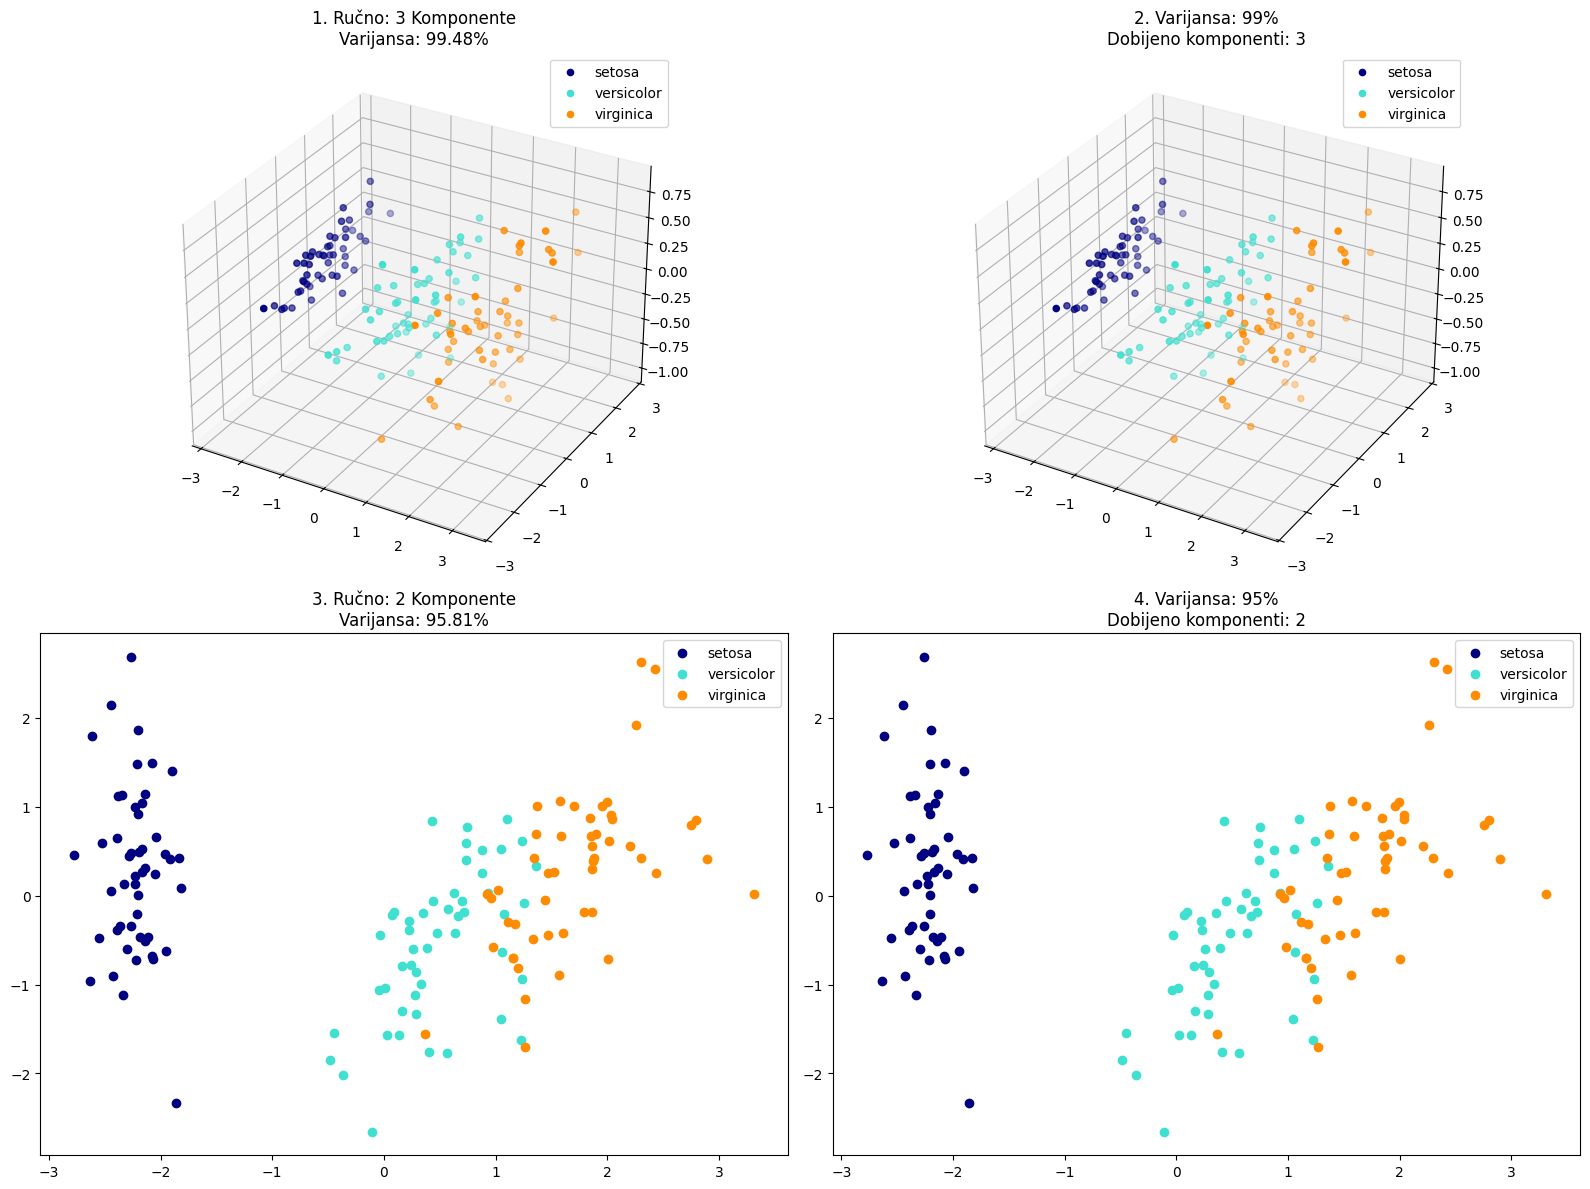

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Očišćemo prethodne grafike iz memorije
plt.close('all')

# 1. Učitavanje i skaliranje podataka
iris = load_iris()
X_scaled = StandardScaler().fit_transform(iris.data)
y = iris.target
names = iris.target_names
colors = ['navy', 'turquoise', 'darkorange']

fig = plt.figure(figsize=(16, 12))

# --- VARIJANTA 1: Ručno na 3 dimenzije (3D prikaz) ---
pca1 = PCA(n_components=3)
X_pca1 = pca1.fit_transform(X_scaled)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
for i, color, name in zip([0, 1, 2], colors, names):
    ax1.scatter(X_pca1[y == i, 0], X_pca1[y == i, 1], X_pca1[y == i, 2], color=color, label=name)
ax1.set_title(f"1. Ručno: 3 Komponente\nVarijansa: {np.sum(pca1.explained_variance_ratio_)*100:.2f}%")
ax1.legend()

# --- VARIJANTA 2: Zadata varijansa 0.99 (3D prikaz) ---
pca2 = PCA(n_components=0.99)
X_pca2 = pca2.fit_transform(X_scaled)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
for i, color, name in zip([0, 1, 2], colors, names):
    ax2.scatter(X_pca2[y == i, 0], X_pca2[y == i, 1], X_pca2[y == i, 2], color=color, label=name)
ax2.set_title(f"2. Varijansa: 99%\nDobijeno komponenti: {pca2.n_components_}")
ax2.legend()

# --- VARIJANTA 3: Ručno na 2 dimenzije (2D prikaz) ---
pca3 = PCA(n_components=2)
X_pca3 = pca3.fit_transform(X_scaled)
ax3 = fig.add_subplot(2, 2, 3)
for i, color, name in zip([0, 1, 2], colors, names):
    ax3.scatter(X_pca3[y == i, 0], X_pca3[y == i, 1], color=color, label=name)
ax3.set_title(f"3. Ručno: 2 Komponente\nVarijansa: {np.sum(pca3.explained_variance_ratio_)*100:.2f}%")
ax3.legend()

# --- VARIJANTA 4: Zadata varijansa 0.95 (2D prikaz) ---
pca4 = PCA(n_components=0.95)
X_pca4 = pca4.fit_transform(X_scaled)
ax4 = fig.add_subplot(2, 2, 4)
for i, color, name in zip([0, 1, 2], colors, names):
    ax4.scatter(X_pca4[y == i, 0], X_pca4[y == i, 1], color=color, label=name)
ax4.set_title(f"4. Varijansa: 95%\nDobijeno komponenti: {pca4.n_components_}")
ax4.legend()

plt.tight_layout()
plt.show()